# Glioblastoma Drug Study

> glioblastoma study redo with latest model

> put geodesic algorithm convergence in methods, we initialize with a slightly perturbed random path and optimize with early stoppage to escape trivial solution and avoid trivial solution convergence 

> put different color, change legend spot on progression plot and inclue more enriched pathways. 

> add which disease you are talking about in the plots Lung Adeno Carcinoma.

In [3]:
import os, sys, json
sys.path.append('../../../')
from tqdm import tqdm
from polygene.eval.metrics import prepare_cell
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, scanpy as sc
from polygene.model.model import load_trained_model
neural_network_path = "/media/lleger/LaCie/mit/runs/polygene_unit_sphere/"

model, tokenizer = load_trained_model(neural_network_path, checkpoint_n=-1)
tokenizer.bypass_inference=True

atlas_path =  "/media/lleger/LaCie/mit/old/disease_vector/vector_data/glioblastoma_study/"
cells = sc.concat([sc.read_h5ad(atlas_path + file) for file in os.listdir(atlas_path) if "h5ad" in file])

cells.obs_names_make_unique()
n_cells_per_drug = int(2.5e3)
indices_to_keep = cells.obs.groupby("drug", observed=True).sample(n=n_cells_per_drug, replace=False).index.unique()
cells = cells[indices_to_keep]

embeddings, labels = np.load("glioblastoma_embeddings.npy"), np.load("glioblastoma_predicted_phenotypes.npy")
#embeddings, labels = [], []
#for cell in tqdm(cells):
#    cell_dict, _ = prepare_cell(cell, tokenizer)
#    cell_dict['input_ids'][1:1+len(tokenizer.phenotypic_types)] = tokenizer.token_to_id_map[tokenizer.mask_token]
#    output = model(**{key: val.to(model.device).unsqueeze(0) for key, val in cell_dict.items()})
#    embeddings.append(output.hidden_states[:, 1+tokenizer.phenotypic_types.index('disease')].detach().cpu().numpy())
#    labels.append(output.logits.squeeze().argmax(dim=-1)[1:1+len(tokenizer.phenotypic_types)].detach().cpu().numpy())
#np.save(arr=np.concatenate(embeddings), file="glioblastoma_embeddings.npy")
#np.save(arr=np.array(labels), file="glioblastoma_predicted_phenotypes.npy")

loading checkpoint-1500000


In [4]:
healthy_cells = sc.read_h5ad(atlas_path + "../glioblastoma_cells.h5ad")
healthy_cells = healthy_cells[(healthy_cells.obs['cell_type'] == 'oligodendrocyte') & (healthy_cells.obs['disease'] == 'normal')]
healthy_embeddings = []
for cell in tqdm(healthy_cells):
    cell_dict, _ = prepare_cell(cell, tokenizer)
    cell_dict['input_ids'][1:1+len(tokenizer.phenotypic_types)] = tokenizer.token_to_id_map[tokenizer.mask_token]
    output = model(**{key: val.to(model.device).unsqueeze(0) for key, val in cell_dict.items()})
    healthy_embeddings.append(output.hidden_states[:, 1+tokenizer.phenotypic_types.index('disease')].detach().cpu().numpy())
healthy_embeddings = np.concatenate(healthy_embeddings)

  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:28<00:00, 71.13it/s]


In [151]:
embeddings, labels = np.load("glioblastoma_embeddings.npy"), np.load("glioblastoma_predicted_phenotypes.npy")
from sklearn.decomposition import PCA
pca = PCA(n_components=2, whiten=True, svd_solver="full", random_state=3)
pca_coordinates = pca.fit_transform(embeddings)

In [8]:
diseases = [tokenizer.flattened_tokens[predicted_idx] for predicted_idx in labels[:, tokenizer.phenotypic_types.index('disease')]]
cell_types = [tokenizer.flattened_tokens[predicted_idx] for predicted_idx in labels[:, tokenizer.phenotypic_types.index('cell_type')]]
tissues = [tokenizer.flattened_tokens[predicted_idx] for predicted_idx in labels[:, tokenizer.phenotypic_types.index('tissue')]]

display(pd.Series(tissues).value_counts().reset_index().head(3), pd.Series(cell_types).value_counts().reset_index().head(3), pd.Series(diseases).value_counts().reset_index().head(3))

,index,0
0,[left_frontal_lobe],15504
1,[right_temporal_lobe],1525
2,[left_temporal_lobe],1269


,index,0
0,[malignant_cell],11698
1,[macrophage],6439
2,[oligodendrocyte],1198


,index,0
0,[glioblastoma],15432
1,[normal],3848
2,[plasma_cell_myeloma],301


In [127]:
# final processing to isolate drug effect on population of GBM malignant cells. 
#final_mask = (pd.Series(diseases).isin(["[normal]", "[glioblastoma]"])) & (pd.Series(cell_types).isin(["[malignant_cell]"]))
#cells = cells[final_mask]
#embeddings = embeddings[final_mask]
#pca_coordinates = pca_coordinates[final_mask]

NameError: name 'pca_coordinates' is not defined

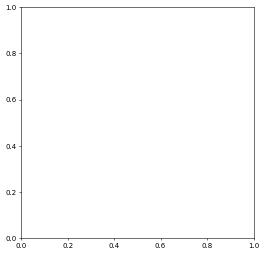

In [6]:

fontsize, dpi = 16, 50
drugs = sorted(np.unique(cells.obs.drug).tolist())
palette = sns.color_palette('cubehelix', n_colors=len(drugs))
fig, ax = plt.subplots(1,1, figsize=(6,6), dpi=dpi)

plt.rcParams['mathtext.fontset'] = "cm"
plt.rcParams['font.family'] = "Latin Modern Roman"
for idx, drug in enumerate(drugs):
    coords = pca_coordinates[cells.obs.drug == drug]
    ax.scatter(coords[:, 0], coords[:, 1], color=palette[idx], s=1, label=drug.split(' ')[-1].replace('(', '').replace(')', '').title(), alpha=1)

ax.spines[['bottom', 'left']].set_linewidth(2)
ax.spines[['top', 'right']].set_linewidth(0)
ax.legend(frameon=False, loc="lower right", fontsize=fontsize, markerscale=5)
ax.tick_params('both', labelsize=fontsize)
ax.set_xticks([])
ax.set_xlabel(f'PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)', fontsize=fontsize)
ax.set_ylabel(f'PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)', fontsize=fontsize)
ax.set_yticks([])
plt.tight_layout()
plt.show()

In [9]:
drug_effectiveness_rank = {
    "treatment: 0.2 uM panobinostat": 1,
    "treatment: 2.5 uM etoposide": 2,
    "treatment: 1.8 nM Ispenisib": 3,
    "treatment: 50 uM Tazemetostat": 4,
    "treatment: 50 nM RO4929097": 5,
    "treatment: 40 nM Ana-12": 6,
    "treatment: vehicle (DMSO)": 7,
    "treatment: none": 8
}
drug_effectiveness_rank = {
    "treatment: 0.2 uM panobinostat": "High Response",
    "treatment: 2.5 uM etoposide": "High Response",
    "treatment: 1.8 nM Ispenisib": "Moderate Response",
    "treatment: 50 uM Tazemetostat": "Moderate Response",
    "treatment: 50 nM RO4929097": "Low Response",
    "treatment: 40 nM Ana-12": "Low Response",
    "treatment: vehicle (DMSO)": "Control",
    "treatment: none": "Control",
}
normal_centroid = healthy_embeddings.mean(axis=0)
vectors = {}
for drug in drugs:
    vectors[drug] = embeddings[(cells.obs.drug == drug) & (np.array(diseases) == "[glioblastoma]") & (np.array(cell_types) == "[oligodendrocyte]")].mean(axis=0) - normal_centroid

baseline_vector = vectors["treatment: none"]
correlations = {}
for drug in drugs: correlations[drug] = np.dot(vectors[drug], baseline_vector) / (np.linalg.norm(vectors[drug]) * np.linalg.norm(baseline_vector))

df = pd.DataFrame.from_dict(correlations, orient="index").sort_values(by=0)
df['ranking'] = drug_effectiveness_rank
df.columns = ['Cosine similarity with disease vector', 'Transcriptional Response']
df.sort_values('Cosine similarity with disease vector')

,Cosine similarity with disease vector,Transcriptional Response
treatment: 40 nM Ana-12,0.896352,Low Response
treatment: 1.8 nM Ispenisib,0.898919,Moderate Response
treatment: 0.2 uM panobinostat,0.901927,High Response
treatment: 2.5 uM etoposide,0.902269,High Response
treatment: 50 nM RO4929097,0.906107,Low Response
treatment: 50 uM Tazemetostat,0.918877,Moderate Response
treatment: vehicle (DMSO),0.923384,Control
treatment: none,1.000000,Control


In [ ]:
drug_effectiveness_rank_2 = {
    "treatment: 0.2 uM panobinostat": 1,
    "treatment: 2.5 uM etoposide": 2,
    "treatment: 1.8 nM Ispenisib": 3,
    "treatment: 50 uM Tazemetostat": 4,
    "treatment: 50 nM RO4929097": 5,
    "treatment: 40 nM Ana-12": 6,
    "treatment: vehicle (DMSO)": 7,
    "treatment: none": 8
}
drug_effectiveness_rank = {
    "treatment: 0.2 uM panobinostat": "High Response",
    "treatment: 2.5 uM etoposide": "High Response",
    "treatment: 1.8 nM Ispenisib": "Moderate Response",
    "treatment: 50 uM Tazemetostat": "Moderate Response",
    "treatment: 50 nM RO4929097": "Low Response",
    "treatment: 40 nM Ana-12": "Low Response",
    "treatment: vehicle (DMSO)": "Control",
    "treatment: none": "Control",
}
normal_centroid = healthy_embeddings.mean(axis=0)
vectors = {}
for drug in drugs:
    vectors[drug] = embeddings[(cells.obs.drug == drug) & (np.array(diseases) == "[glioblastoma]")].mean(axis=0) - normal_centroid

baseline_vector = vectors["treatment: none"]
correlations = {}
for drug in drugs: correlations[drug] = np.dot(vectors[drug], baseline_vector) / (np.linalg.norm(vectors[drug]) * np.linalg.norm(baseline_vector))

df = pd.DataFrame.from_dict(correlations, orient="index").sort_values(by=0)
df['ranking'] = drug_effectiveness_rank
df.columns = ['Cosine similarity with disease vector', 'Transcriptional Response']
df['Study Ranking'] = drug_effectiveness_rank_2
df.index = [x.split(' ')[-1].replace('(', '').replace(')', '').title() for x in df.index.tolist()]
df = df.sort_values('Cosine similarity with disease vector')
df.to_latex()

,Cosine similarity with disease vector,Transcriptional Response,Study Ranking
Panobinostat,0.937357,High Response,1
Ro4929097,0.937391,Low Response,5
Ispenisib,0.946579,Moderate Response,3
Tazemetostat,0.949530,Moderate Response,4
Ana-12,0.949881,Low Response,6
Etoposide,0.955576,High Response,2
Dmso,0.958046,Control,7
None,1.000000,Control,8


In [15]:
print(df.to_latex(
    index=True,
    escape=False,
    column_format='lcc',
    float_format=lambda x: f'{x:.3f}',
    bold_rows=False
).replace('\\toprule', '\\toprule').replace('\\midrule', '\\midrule').replace('\\bottomrule', '\\bottomrule'))

\begin{tabular}{lcc}
\toprule
{} &  Cosine similarity with disease vector & Transcriptional Response &  Study Ranking \\
\midrule
Panobinostat &                                  0.937 &            High Response &              1 \\
Ro4929097    &                                  0.937 &             Low Response &              5 \\
Ispenisib    &                                  0.947 &        Moderate Response &              3 \\
Tazemetostat &                                  0.950 &        Moderate Response &              4 \\
Ana-12       &                                  0.950 &             Low Response &              6 \\
Etoposide    &                                  0.956 &            High Response &              2 \\
Dmso         &                                  0.958 &                  Control &              7 \\
None         &                                  1.000 &                  Control &              8 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_3150198/394237236.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(df.to_latex(


In [159]:
drug_effectiveness_rank = {
    "treatment: 0.2 uM panobinostat": 1,
    "treatment: 2.5 uM etoposide": 2,
    "treatment: 1.8 nM Ispenisib": 3,
    "treatment: 50 uM Tazemetostat": 4,
    "treatment: 50 nM RO4929097": 5,
    "treatment: 40 nM Ana-12": 6,
    "treatment: vehicle (DMSO)": 7,
    "treatment: none": 8
}
normal_centroid = healthy_embeddings.mean(axis=0)
vectors = {}
for drug in drugs:
    vectors[drug] = embeddings[(cells.obs.drug == drug)].mean(axis=0) - embeddings[(cells.obs.drug == "treatment: none")].mean(axis=0)

baseline_vector = vectors["treatment: none"] - normal_centroid
correlations = {}
magnitude = {}
for drug in drugs:
    correlations[drug] = np.dot(vectors[drug], baseline_vector) / (np.linalg.norm(vectors[drug]) * np.linalg.norm(baseline_vector))
    magnitude[drug] = np.linalg.norm(vectors[drug])

df = pd.DataFrame.from_dict(correlations, orient="index").sort_values(by=0)
df['ranking'] = drug_effectiveness_rank
df['mag'] = magnitude
df.sort_values(0)

/tmp/ipykernel_3139179/2489692637.py:20: RuntimeWarning: invalid value encountered in scalar divide
  correlations[drug] = np.dot(vectors[drug], baseline_vector) / (np.linalg.norm(vectors[drug]) * np.linalg.norm(baseline_vector))


,0,ranking,mag
treatment: 0.2 uM panobinostat,-0.033184,1,0.302897
treatment: vehicle (DMSO),-0.030800,7,0.265196
treatment: 50 nM RO4929097,-0.002231,5,0.325017
treatment: 2.5 uM etoposide,0.012218,2,0.280092
treatment: 40 nM Ana-12,0.013669,6,0.298417
treatment: 1.8 nM Ispenisib,0.032289,3,0.291163
treatment: 50 uM Tazemetostat,0.038919,4,0.279062
treatment: none,NaN,8,0.000000


In [136]:
df.sort_values(0)

,0,ranking
treatment: 50 nM RO4929097,0.936359,5
treatment: 0.2 uM panobinostat,0.941481,1
treatment: 40 nM Ana-12,0.946770,6
treatment: 1.8 nM Ispenisib,0.949717,3
treatment: 2.5 uM etoposide,0.951785,2
treatment: 50 uM Tazemetostat,0.953982,4
treatment: vehicle (DMSO),0.956249,7
treatment: none,1.000000,8


In [101]:
import pandas as pd
import numpy as np

drug_effectiveness_rank = {
    "treatment: 0.2 uM panobinostat": 1,
    "treatment: 2.5 uM etoposide": 2,
    "treatment: 1.8 nM Ispenisib": 3,
    "treatment: 50 uM Tazemetostat": 4,
    "treatment: 50 nM RO4929097": 5,
    "treatment: 40 nM Ana-12": 6,
    "treatment: vehicle (DMSO)": 7,
    "treatment: none": 8
}

normal_centroid = embeddings[(np.array(diseases)[final_mask] == "[normal]")].mean(axis=0)
untreated_centroid = embeddings[(cells.obs.drug == "treatment: none")].mean(axis=0)
baseline_vector = normal_centroid - untreated_centroid

results = {}
for drug in drug_effectiveness_rank.keys():
    drug_centroid = embeddings[(cells.obs.drug == drug) & (np.array(diseases)[final_mask] == "[glioblastoma]")].mean(axis=0)
    drug_vector = drug_centroid - untreated_centroid
    
    magnitude = np.linalg.norm(drug_vector)
    direction = np.corrcoef(drug_vector, baseline_vector)[0, 1]
    
    results[drug] = {
        'magnitude': magnitude,
        'direction_to_normal': direction,
        'reported_rank': drug_effectiveness_rank[drug]
    }

df = pd.DataFrame.from_dict(results, orient="index").sort_values(by='reported_rank')

In [103]:
df.sort_values("direction_to_normal")

,magnitude,direction_to_normal,reported_rank
treatment: none,0.062882,-0.780767,8
treatment: 2.5 uM etoposide,0.307738,0.001695,2
treatment: 0.2 uM panobinostat,0.334668,0.025286,1
treatment: vehicle (DMSO),0.291490,0.121156,7
treatment: 1.8 nM Ispenisib,0.359252,0.162064,3
treatment: 50 nM RO4929097,0.368302,0.198628,5
treatment: 50 uM Tazemetostat,0.319552,0.269666,4
treatment: 40 nM Ana-12,0.337156,0.379165,6


In [ ]:
baseline_vector = centroids['treatment: none'] - normal_centroid
correlations = {}
for drug in drugs: correlations[drug] = np.dot(vectors[drug], baseline_vector)


/home/lleger/miniconda3/envs/gene/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/lleger/miniconda3/envs/gene/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [89]:
df = pd.DataFrame.from_dict(correlations, orient="index").sort_values(by=0)
df['ranking'] = drug_effectiveness_rank
df

,0,ranking
treatment: 40 nM Ana-12,-0.536643,6
treatment: 50 uM Tazemetostat,-0.390698,4
treatment: 1.8 nM Ispenisib,-0.293499,3
treatment: 50 nM RO4929097,-0.283005,5
treatment: vehicle (DMSO),-0.208917,7
treatment: 0.2 uM panobinostat,-0.110127,1
treatment: 2.5 uM etoposide,-0.066242,2
treatment: none,NaN,8
